In [6]:
# here 
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from chronos import ChronosPipeline
from scipy.signal import butter, lfilter
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.filters.hp_filter import hpfilter


In [7]:
# ========================
# Paths and core settings
# ========================
PROJECT_ROOT = Path("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay")
DATA_PATH = PROJECT_ROOT / "DataSets/SSMI cleaned/SSMI_cleaned.csv"
BASELINE_PATH = PROJECT_ROOT / "Chronos/ChronosBase_SSMI_Metrics.npz"
OUTPUT_DIR = PROJECT_ROOT / "Chronos"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = "amazon/chronos-t5-base"
DEVICE_MAP = "mps"  # set to "cpu" if needed
DTYPE = torch.float32

CONTEXT_WINDOW = 180
FORECAST_HORIZON = 15
STEP_SIZE = 30
NUM_SAMPLES = 20

FILTER_CONFIGS = {
    "Moving Average": [
        {"window": 10},
        {"window": 30},
        {"window": 60},
    ],
    "Butterworth": [
        {"cutoff": 0.05, "order": 2},
        {"cutoff": 0.10, "order": 2},
        {"cutoff": 0.20, "order": 2},
    ],
    "HP Filter": [
        {"lambda": 100},
        {"lambda": 1600},
        {"lambda": 10000},
    ],
    "Kalman Filter": [
        {"process_noise": 0.001},
        {"process_noise": 0.01},
        {"process_noise": 0.1},
    ],
}

LOWER_IS_BETTER = {"rmse", "mape"}
METRIC_COLUMNS = ["rmse", "mape", "pearson_r2", "directional_accuracy"]


In [8]:
# ========================
# Data + baseline
# ========================
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
y = df["Adj Close"].values.astype(float)

if not BASELINE_PATH.exists():
    raise FileNotFoundError(f"Baseline file not found: {BASELINE_PATH}")

baseline_npz = np.load(BASELINE_PATH)
baseline_metrics = {
    "rmse": float(np.median(baseline_npz["rmse"])),
    "mape": float(np.median(baseline_npz["mape"])),
    "pearson_r2": float(np.median(baseline_npz["pearson_coefficients"])),
    "directional_accuracy": float(np.mean(baseline_npz["directional_hits"]) * 100.0),
}

print("Baseline (Chronos zero-shot)")
for metric_name, value in baseline_metrics.items():
    print(f"- {metric_name}: {value:.4f}")


Baseline (Chronos zero-shot)
- rmse: 130.0760
- mape: 1.7208
- pearson_r2: 0.1525
- directional_accuracy: 33.5207


In [9]:
# ========================
# Filter decomposition helpers
# ========================
def decompose_moving_average(y_context, window):
    low = pd.Series(y_context).rolling(window=int(window), min_periods=1).mean().to_numpy()
    high = y_context - low
    return low.astype(float), high.astype(float)


def decompose_butterworth(y_context, cutoff, order):
    b, a = butter(int(order), float(cutoff), btype="low")
    low = lfilter(b, a, y_context)
    high = y_context - low
    return low.astype(float), high.astype(float)


def decompose_hp_filter(y_context, lam):
    cycle, trend = hpfilter(y_context, lamb=float(lam))
    low = np.asarray(trend, dtype=float)
    high = np.asarray(cycle, dtype=float)
    return low, high


def decompose_kalman(y_context, process_noise, measurement_noise=1.0):
    q = float(process_noise)
    r = float(measurement_noise)

    x = float(y_context[0])
    p = 1.0
    low = np.zeros_like(y_context, dtype=float)

    for i, z in enumerate(y_context):
        p = p + q
        k = p / (p + r)
        x = x + k * (float(z) - x)
        p = (1.0 - k) * p
        low[i] = x

    high = y_context - low
    return low, high


def decompose_signal(y_context, filter_name, config):
    if filter_name == "Moving Average":
        return decompose_moving_average(y_context, window=config["window"])
    if filter_name == "Butterworth":
        return decompose_butterworth(y_context, cutoff=config["cutoff"], order=config["order"])
    if filter_name == "HP Filter":
        return decompose_hp_filter(y_context, lam=config["lambda"])
    if filter_name == "Kalman Filter":
        return decompose_kalman(y_context, process_noise=config["process_noise"])
    raise ValueError(f"Unknown filter: {filter_name}")


In [10]:
# ========================
# Experiment runner
# ========================
def evaluate_filter_config(
    pipeline,
    y_values,
    filter_name,
    filter_config,
    context_window=CONTEXT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    step_size=STEP_SIZE,
    num_samples=NUM_SAMPLES,
):
    rmse_list = []
    mape_list = []
    r2_list = []
    directional_hits = []

    total_samples = len(y_values)
    num_segments = (total_samples - context_window) // step_size

    for segment in range(num_segments):
        start_context = segment * step_size
        end_context = start_context + context_window

        if end_context + forecast_horizon > total_samples:
            break

        y_context = y_values[start_context:end_context]
        y_true = y_values[end_context:end_context + forecast_horizon]

        low_np, high_np = decompose_signal(y_context, filter_name, filter_config)

        context_low = torch.tensor(low_np.copy(), dtype=torch.float32)
        context_high = torch.tensor(high_np.copy(), dtype=torch.float32)

        forecast_low = pipeline.predict(
            context_low,
            prediction_length=forecast_horizon,
            num_samples=num_samples,
        )
        forecast_high = pipeline.predict(
            context_high,
            prediction_length=forecast_horizon,
            num_samples=num_samples,
        )

        pred_low = np.median(forecast_low[0].numpy(), axis=0)
        pred_high = np.median(forecast_high[0].numpy(), axis=0)
        y_pred = pred_low + pred_high

        prev_actual = np.concatenate([[y_values[end_context - 1]], y_true[:-1]])
        prev_pred = np.concatenate([[y_values[end_context - 1]], y_pred[:-1]])
        actual_direction = np.sign(y_true - prev_actual)
        pred_direction = np.sign(y_pred - prev_pred)
        hits = (actual_direction == pred_direction).astype(int)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
        r2 = pearsonr(y_true, y_pred).statistic ** 2

        rmse_list.append(rmse)
        mape_list.append(mape)
        r2_list.append(r2)
        directional_hits.extend(hits.tolist())

    return {
        "rmse": np.array(rmse_list, dtype=float),
        "mape": np.array(mape_list, dtype=float),
        "pearson_r2": np.array(r2_list, dtype=float),
        "directional_hits": np.array(directional_hits, dtype=float),
    }


def summarize_metrics(metric_arrays):
    return {
        "rmse": float(np.median(metric_arrays["rmse"])) if len(metric_arrays["rmse"]) else np.nan,
        "mape": float(np.median(metric_arrays["mape"])) if len(metric_arrays["mape"]) else np.nan,
        "pearson_r2": float(np.median(metric_arrays["pearson_r2"])) if len(metric_arrays["pearson_r2"]) else np.nan,
        "directional_accuracy": float(np.mean(metric_arrays["directional_hits"]) * 100.0) if len(metric_arrays["directional_hits"]) else np.nan,
    }


In [11]:
# ========================
# Run all experiments
# ========================
pipeline = ChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE_MAP,
    torch_dtype=DTYPE,
)

rows = []
all_metric_arrays = {}

for filter_name, configs in FILTER_CONFIGS.items():
    for idx, config in enumerate(configs, start=1):
        run_name = f"{filter_name} | cfg_{idx}"
        print(f"Running {run_name}: {config}")

        metric_arrays = evaluate_filter_config(
            pipeline=pipeline,
            y_values=y,
            filter_name=filter_name,
            filter_config=config,
        )

        summary = summarize_metrics(metric_arrays)

        row = {
            "filter": filter_name,
            "config_id": idx,
            "config": str(config),
            **summary,
        }
        rows.append(row)
        all_metric_arrays[(filter_name, idx)] = metric_arrays

results_df = pd.DataFrame(rows).sort_values(["filter", "config_id"]).reset_index(drop=True)
results_df


`torch_dtype` is deprecated! Use `dtype` instead!


Running Moving Average | cfg_1: {'window': 10}
Running Moving Average | cfg_2: {'window': 30}
Running Moving Average | cfg_3: {'window': 60}
Running Butterworth | cfg_1: {'cutoff': 0.05, 'order': 2}
Running Butterworth | cfg_2: {'cutoff': 0.1, 'order': 2}
Running Butterworth | cfg_3: {'cutoff': 0.2, 'order': 2}
Running HP Filter | cfg_1: {'lambda': 100}
Running HP Filter | cfg_2: {'lambda': 1600}
Running HP Filter | cfg_3: {'lambda': 10000}
Running Kalman Filter | cfg_1: {'process_noise': 0.001}
Running Kalman Filter | cfg_2: {'process_noise': 0.01}
Running Kalman Filter | cfg_3: {'process_noise': 0.1}


,filter,config_id,config,rmse,mape,pearson_r2,directional_accuracy
0,Butterworth,1,"{'cutoff': 0.05, 'order': 2}",173.757781,2.351907,0.353064,48.246319
1,Butterworth,2,"{'cutoff': 0.1, 'order': 2}",136.716464,1.907369,0.292571,49.585007
2,Butterworth,3,"{'cutoff': 0.2, 'order': 2}",132.214175,1.832396,0.221733,49.210174
3,HP Filter,1,{'lambda': 100},134.273082,1.809019,0.271473,50.575636
4,HP Filter,2,{'lambda': 1600},147.607681,1.994218,0.329376,49.852744
5,HP Filter,3,{'lambda': 10000},133.251479,1.829341,0.324206,50.120482
6,Kalman Filter,1,{'process_noise': 0.001},125.039271,1.674501,0.261308,48.246319
7,Kalman Filter,2,{'process_noise': 0.01},122.452207,1.715599,0.266642,50.816600
8,Kalman Filter,3,{'process_noise': 0.1},131.734445,1.717298,0.199769,49.183400
9,Moving Average,1,{'window': 10},126.562084,1.600557,0.251962,48.995984


In [12]:
# ========================
# Best hyperparameters per metric (global)
# ========================
best_global = []

for metric in METRIC_COLUMNS:
    best_idx = results_df[metric].idxmin() if metric in LOWER_IS_BETTER else results_df[metric].idxmax()
    row = results_df.loc[best_idx]
    best_global.append({
        "metric": metric,
        "filter": row["filter"],
        "config_id": int(row["config_id"]),
        "config": row["config"],
        "metric_value": float(row[metric]),
    })

best_global_df = pd.DataFrame(best_global)
best_global_df


,metric,filter,config_id,config,metric_value
0,rmse,Moving Average,2,{'window': 30},122.108089
1,mape,Moving Average,1,{'window': 10},1.600557
2,pearson_r2,Butterworth,1,"{'cutoff': 0.05, 'order': 2}",0.353064
3,directional_accuracy,Kalman Filter,2,{'process_noise': 0.01},50.816600


In [13]:
# ========================
# Save outputs (robust)
# ========================

# Rebuild best_by_filter_metric_df if missing
if "best_by_filter_metric_df" not in globals():
    best_by_filter_metric = []
    for filter_name, group in results_df.groupby("filter"):
        for metric in METRIC_COLUMNS:
            best_idx = group[metric].idxmin() if metric in LOWER_IS_BETTER else group[metric].idxmax()
            best_row = results_df.loc[best_idx]
            best_by_filter_metric.append({
                "filter": filter_name,
                "metric": metric,
                "best_config_id": int(best_row["config_id"]),
                "best_config": best_row["config"],
                "metric_value": float(best_row[metric]),
            })
    best_by_filter_metric_df = pd.DataFrame(best_by_filter_metric)

# Rebuild best_global_df if missing
if "best_global_df" not in globals():
    best_global = []
    for metric in METRIC_COLUMNS:
        best_idx = results_df[metric].idxmin() if metric in LOWER_IS_BETTER else results_df[metric].idxmax()
        row = results_df.loc[best_idx]
        best_global.append({
            "metric": metric,
            "filter": row["filter"],
            "config_id": int(row["config_id"]),
            "config": row["config"],
            "metric_value": float(row[metric]),
        })
    best_global_df = pd.DataFrame(best_global)

results_df.to_csv(OUTPUT_DIR / "Chronos_Filter_Hyperparam_Results.csv", index=False)
best_by_filter_metric_df.to_csv(OUTPUT_DIR / "Chronos_Filter_BestConfig_PerMetric_PerFilter.csv", index=False)
best_global_df.to_csv(OUTPUT_DIR / "Chronos_Filter_BestConfig_Global_PerMetric.csv", index=False)

results_df.head()


,filter,config_id,config,rmse,mape,pearson_r2,directional_accuracy
0,Butterworth,1,"{'cutoff': 0.05, 'order': 2}",173.757781,2.351907,0.353064,48.246319
1,Butterworth,2,"{'cutoff': 0.1, 'order': 2}",136.716464,1.907369,0.292571,49.585007
2,Butterworth,3,"{'cutoff': 0.2, 'order': 2}",132.214175,1.832396,0.221733,49.210174
3,HP Filter,1,{'lambda': 100},134.273082,1.809019,0.271473,50.575636
4,HP Filter,2,{'lambda': 1600},147.607681,1.994218,0.329376,49.852744


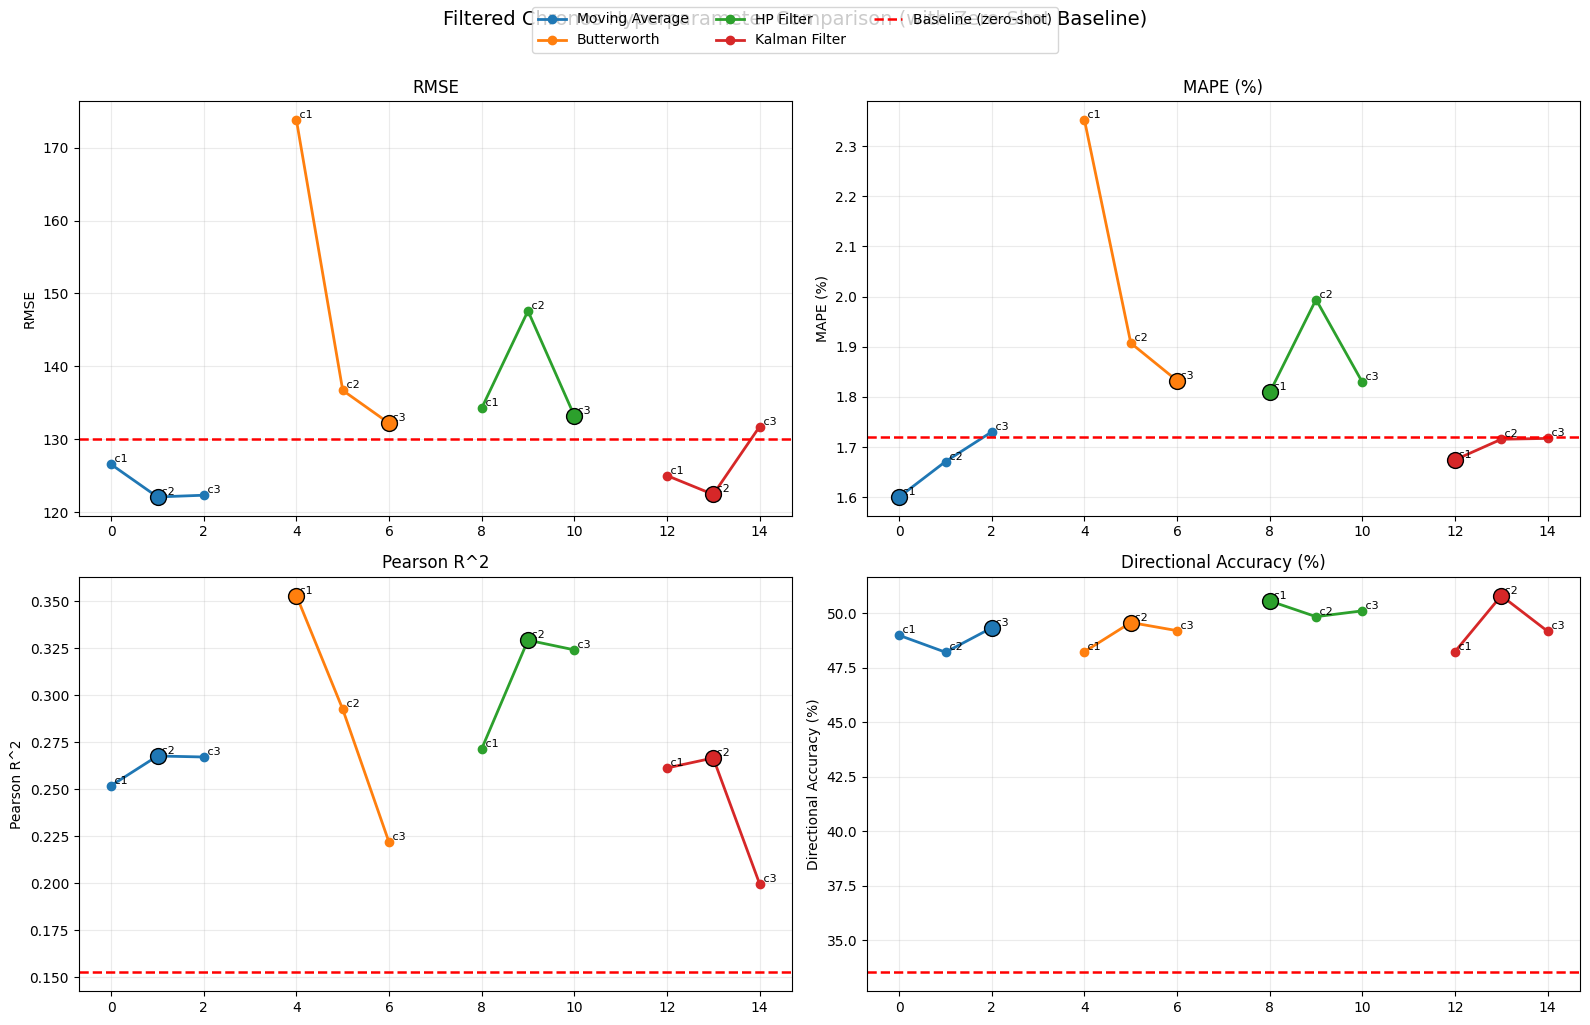

In [14]:
# ========================
# Plot: 3 hyperparams per filter + baseline
# ========================
metric_labels = {
    "rmse": "RMSE",
    "mape": "MAPE (%)",
    "pearson_r2": "Pearson R^2",
    "directional_accuracy": "Directional Accuracy (%)",
}

filters = list(FILTER_CONFIGS.keys())
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for ax, metric in zip(axes, METRIC_COLUMNS):
    baseline_value = baseline_metrics[metric]

    for i, filter_name in enumerate(filters):
        subset = results_df[results_df["filter"] == filter_name].sort_values("config_id")
        x = np.arange(len(subset)) + i * (len(subset) + 1)
        y_vals = subset[metric].values

        ax.plot(x, y_vals, marker="o", linewidth=2, label=filter_name)

        best_idx_local = np.argmin(y_vals) if metric in LOWER_IS_BETTER else np.argmax(y_vals)
        ax.scatter(
            [x[best_idx_local]],
            [y_vals[best_idx_local]],
            s=130,
            edgecolor="black",
            linewidth=1.0,
            zorder=5,
        )

        for j, cfg_id in enumerate(subset["config_id"].values):
            ax.text(x[j], y_vals[j], f" c{cfg_id}", fontsize=8, va="bottom")

    ax.axhline(
        baseline_value,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label="Baseline (zero-shot)",
    )

    ax.set_title(metric_labels[metric])
    ax.set_ylabel(metric_labels[metric])
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
dedup = dict(zip(labels, handles))
fig.legend(dedup.values(), dedup.keys(), loc="upper center", ncol=3, frameon=True)

fig.suptitle("Filtered Chronos Hyperparameter Comparison (with Zero-Shot Baseline)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


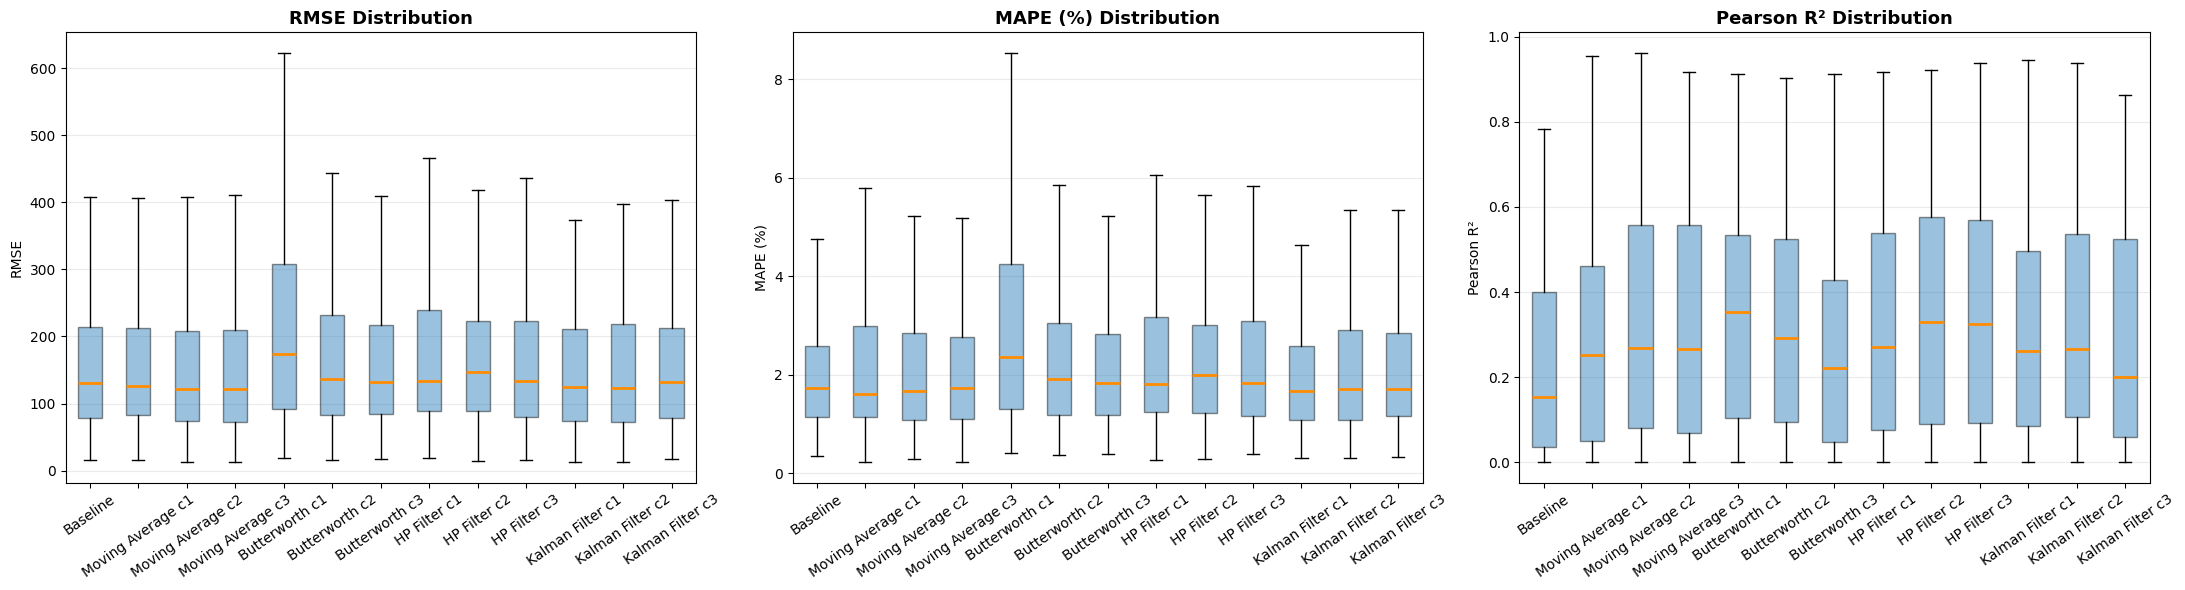

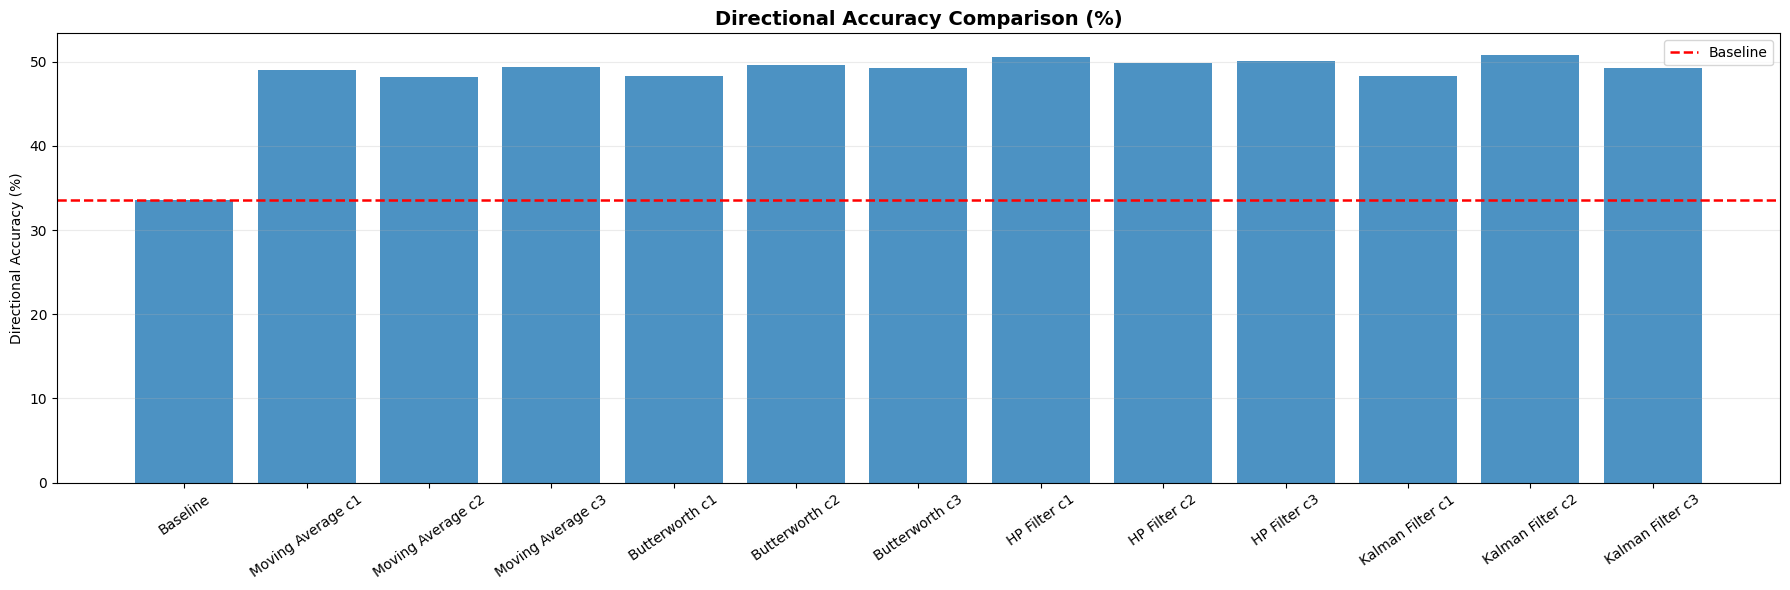

In [15]:
# ========================
# Box plots (RMSE, MAPE, R²) + Bar chart (Directional Accuracy)
# ========================
import numpy as np
import matplotlib.pyplot as plt

baseline_npz = np.load(BASELINE_PATH)

def get_directional_value(metric_arrays):
    # Mean hit-rate across all forecasted days (%)
    return float(np.mean(metric_arrays["directional_hits"]) * 100.0)

# ----- Boxplots for distribution metrics -----
box_metric_defs = [
    ("rmse", "RMSE", baseline_npz["rmse"]),
    ("mape", "MAPE (%)", baseline_npz["mape"]),
    ("pearson_r2", "Pearson R²", baseline_npz["pearson_coefficients"]),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (metric_key, metric_label, baseline_series) in zip(axes, box_metric_defs):
    plot_data = [baseline_series]
    plot_labels = ["Baseline"]

    for filter_name, configs in FILTER_CONFIGS.items():
        for cfg_id in range(1, len(configs) + 1):
            arr = all_metric_arrays[(filter_name, cfg_id)][metric_key]
            plot_data.append(arr)
            plot_labels.append(f"{filter_name} c{cfg_id}")

    bp = ax.boxplot(
        plot_data,
        labels=plot_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color="darkorange", linewidth=2),
    )
    for patch in bp["boxes"]:
        patch.set_alpha(0.45)

    ax.set_title(f"{metric_label} Distribution", fontsize=13, weight="bold")
    ax.set_ylabel(metric_label)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

# ----- Bar chart for directional accuracy -----
labels = ["Baseline"]
values = [float(np.mean(baseline_npz["directional_hits"]) * 100.0)]

for filter_name, configs in FILTER_CONFIGS.items():
    for cfg_id in range(1, len(configs) + 1):
        labels.append(f"{filter_name} c{cfg_id}")
        values.append(get_directional_value(all_metric_arrays[(filter_name, cfg_id)]))

plt.figure(figsize=(18, 6))
bars = plt.bar(labels, values, alpha=0.8)
plt.axhline(values[0], color="red", linestyle="--", linewidth=1.8, label="Baseline")
plt.title("Directional Accuracy Comparison (%)", fontsize=14, weight="bold")
plt.ylabel("Directional Accuracy (%)")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# ========================
# Print best config per filter + baseline comparison
# ========================

TARGET_METRIC = "directional_accuracy"   # choose: "rmse", "mape", "pearson_r2", "directional_accuracy"
LOWER_IS_BETTER = {"rmse", "mape"}

# baseline from your zero-shot file
baseline = {
    "rmse": float(np.median(baseline_npz["rmse"])),
    "mape": float(np.median(baseline_npz["mape"])),
    "pearson_r2": float(np.median(baseline_npz["pearson_coefficients"])),
    "directional_accuracy": float(np.mean(baseline_npz["directional_hits"]) * 100.0),
}

print("Baseline (Chronos Zero-Shot)")
print(f"  RMSE: {baseline['rmse']:.4f}")
print(f"  MAPE: {baseline['mape']:.4f}%")
print(f"  Pearson R²: {baseline['pearson_r2']:.4f}")
print(f"  Directional Accuracy: {baseline['directional_accuracy']:.2f}%")
print("=" * 70)

for filter_name, g in results_df.groupby("filter"):
    g = g.sort_values("config_id")
    best_idx = g[TARGET_METRIC].idxmin() if TARGET_METRIC in LOWER_IS_BETTER else g[TARGET_METRIC].idxmax()
    row = results_df.loc[best_idx]

    print(f"{filter_name}")
    print(f"  Best config (by {TARGET_METRIC}): c{int(row['config_id'])} -> {row['config']}")
    print(f"  RMSE: {row['rmse']:.4f} (Δ vs baseline: {row['rmse'] - baseline['rmse']:+.4f})")
    print(f"  MAPE: {row['mape']:.4f}% (Δ vs baseline: {row['mape'] - baseline['mape']:+.4f}%)")
    print(f"  Pearson R²: {row['pearson_r2']:.4f} (Δ vs baseline: {row['pearson_r2'] - baseline['pearson_r2']:+.4f})")
    print(f"  Directional Accuracy: {row['directional_accuracy']:.2f}% (Δ vs baseline: {row['directional_accuracy'] - baseline['directional_accuracy']:+.2f}%)")
    print("-" * 70)


Baseline (Chronos Zero-Shot)
  RMSE: 130.0760
  MAPE: 1.7208%
  Pearson R²: 0.1525
  Directional Accuracy: 33.52%
Butterworth
  Best config (by directional_accuracy): c2 -> {'cutoff': 0.1, 'order': 2}
  RMSE: 136.7165 (Δ vs baseline: +6.6405)
  MAPE: 1.9074% (Δ vs baseline: +0.1866%)
  Pearson R²: 0.2926 (Δ vs baseline: +0.1401)
  Directional Accuracy: 49.59% (Δ vs baseline: +16.06%)
----------------------------------------------------------------------
HP Filter
  Best config (by directional_accuracy): c1 -> {'lambda': 100}
  RMSE: 134.2731 (Δ vs baseline: +4.1971)
  MAPE: 1.8090% (Δ vs baseline: +0.0882%)
  Pearson R²: 0.2715 (Δ vs baseline: +0.1190)
  Directional Accuracy: 50.58% (Δ vs baseline: +17.05%)
----------------------------------------------------------------------
Kalman Filter
  Best config (by directional_accuracy): c2 -> {'process_noise': 0.01}
  RMSE: 122.4522 (Δ vs baseline: -7.6238)
  MAPE: 1.7156% (Δ vs baseline: -0.0052%)
  Pearson R²: 0.2666 (Δ vs baseline: +0.114

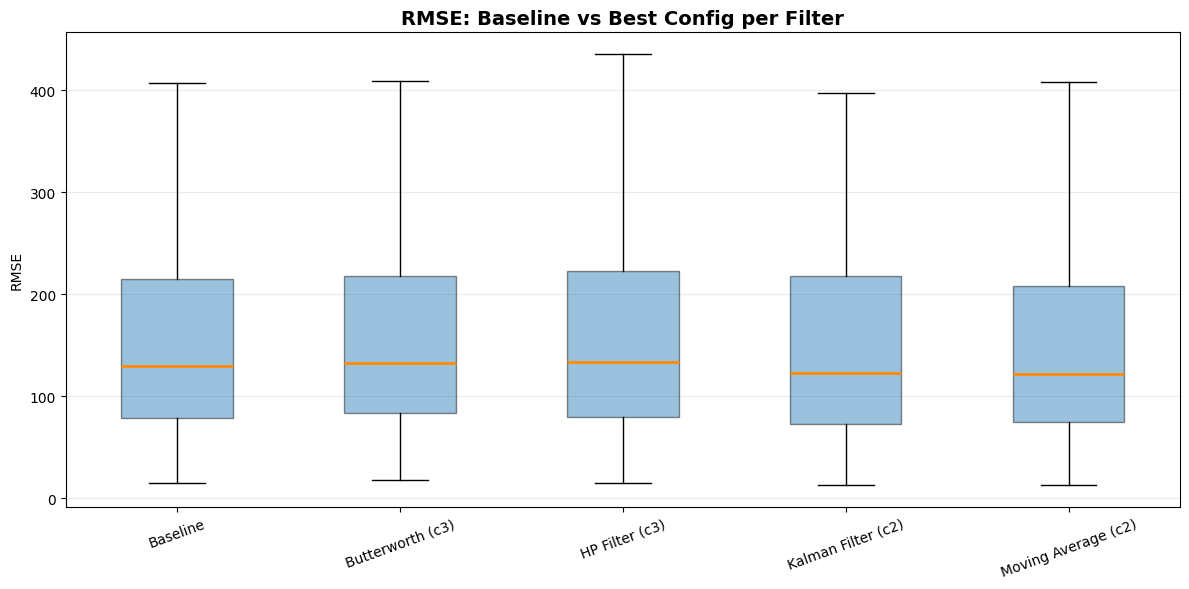

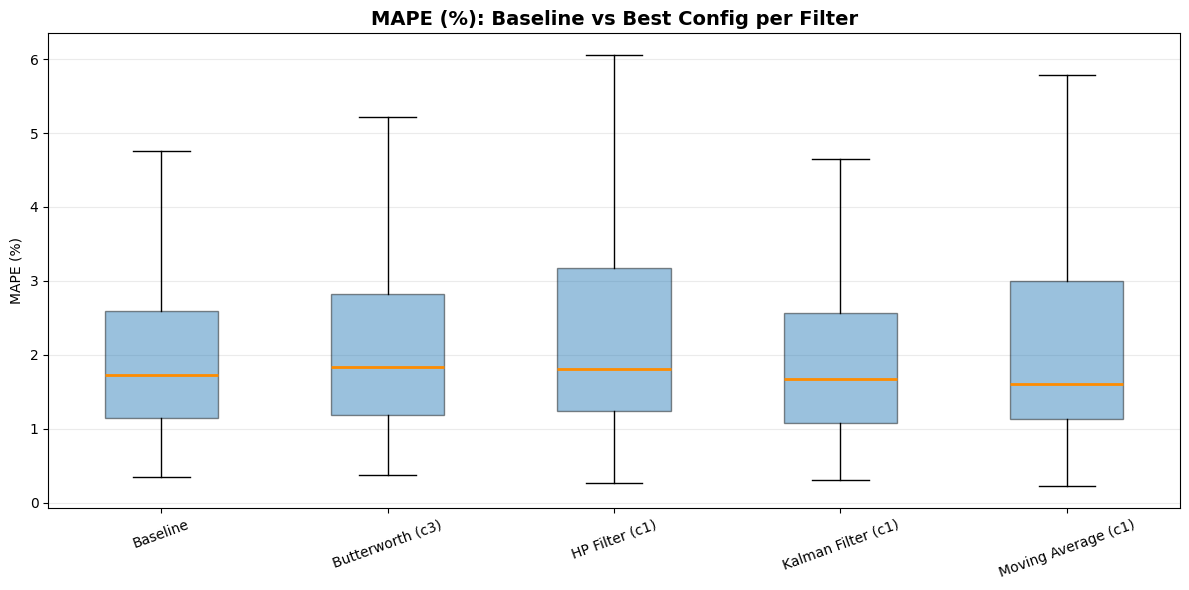

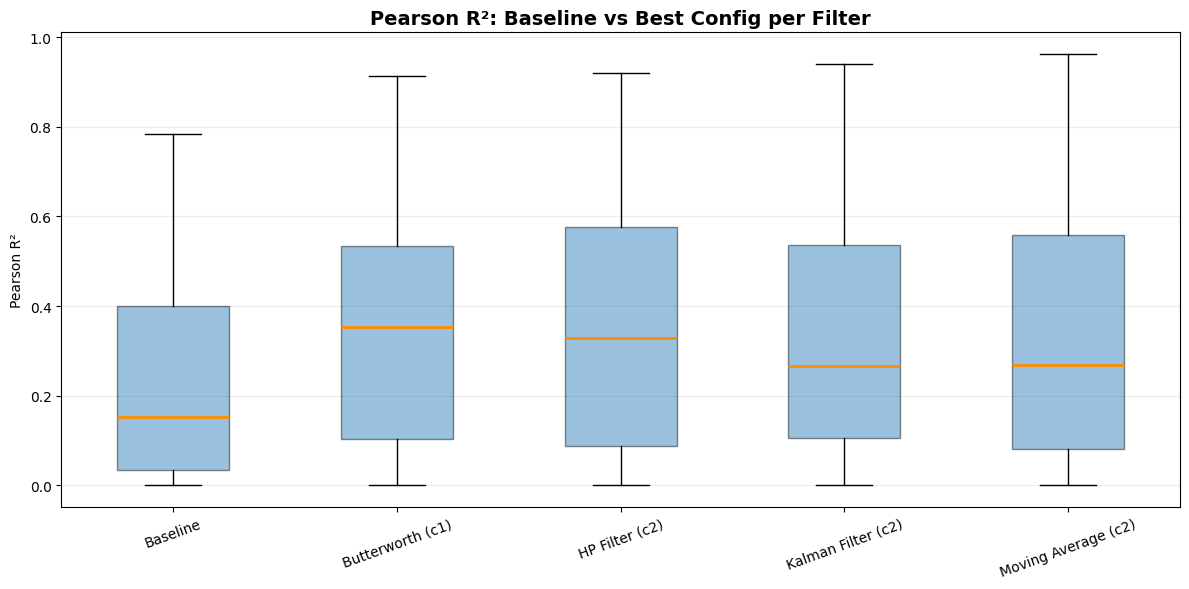

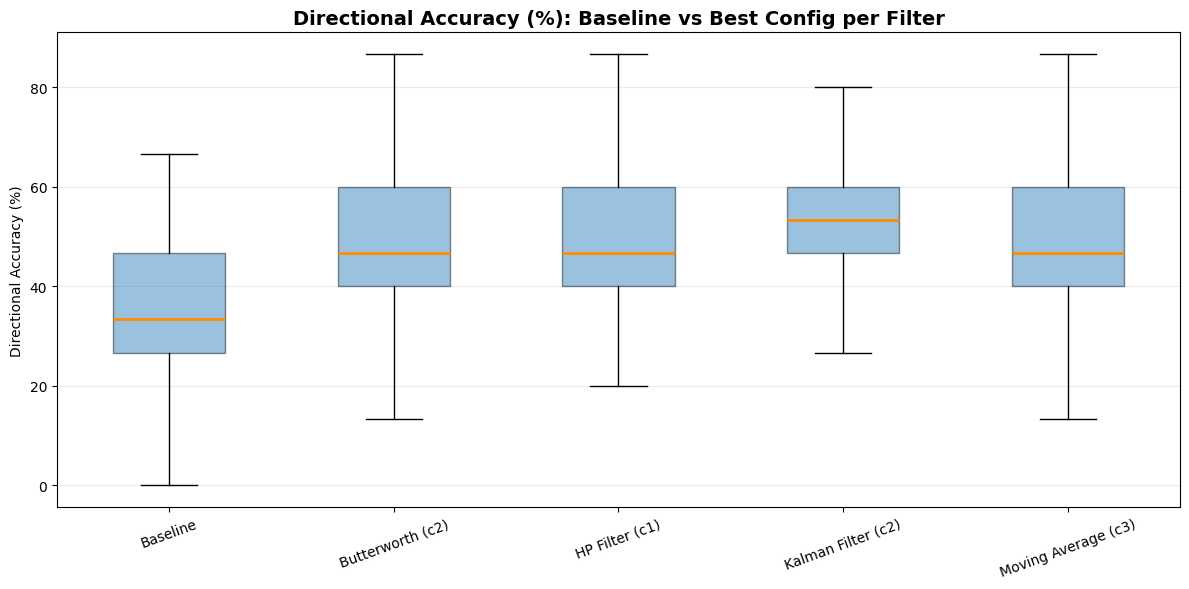

In [17]:
# ========================
# Per-metric boxplot: Baseline + best config per filter (5 boxes)
# ========================
import numpy as np
import matplotlib.pyplot as plt

baseline_npz = np.load(BASELINE_PATH)

def to_segment_directional_accuracy(hits_array, forecast_horizon):
    hits = np.asarray(hits_array, dtype=float)
    n_full = len(hits) // forecast_horizon
    if n_full == 0:
        return np.array([])
    return hits[: n_full * forecast_horizon].reshape(n_full, forecast_horizon).mean(axis=1) * 100.0

def get_series(metric_key, filter_name=None, cfg_id=None):
    # Baseline
    if filter_name is None:
        if metric_key == "rmse":
            return baseline_npz["rmse"]
        if metric_key == "mape":
            return baseline_npz["mape"]
        if metric_key == "pearson_r2":
            return baseline_npz["pearson_coefficients"]
        if metric_key == "directional_accuracy":
            h = int(baseline_npz["forecast_horizon"]) if "forecast_horizon" in baseline_npz.files else FORECAST_HORIZON
            return to_segment_directional_accuracy(baseline_npz["directional_hits"], h)

    # Filtered run
    arr = all_metric_arrays[(filter_name, int(cfg_id))]
    if metric_key == "directional_accuracy":
        return to_segment_directional_accuracy(arr["directional_hits"], FORECAST_HORIZON)
    return arr[metric_key]

metric_defs = [
    ("rmse", "RMSE"),
    ("mape", "MAPE (%)"),
    ("pearson_r2", "Pearson R²"),
    ("directional_accuracy", "Directional Accuracy (%)"),
]

for metric_key, metric_title in metric_defs:
    plot_data = [get_series(metric_key)]
    plot_labels = ["Baseline"]

    # pick best config per filter for THIS metric
    for filter_name, g in results_df.groupby("filter"):
        g = g.sort_values("config_id")
        if metric_key in {"rmse", "mape"}:
            best_idx = g[metric_key].idxmin()
        else:
            best_idx = g[metric_key].idxmax()

        best_row = results_df.loc[best_idx]
        best_cfg_id = int(best_row["config_id"])

        plot_data.append(get_series(metric_key, filter_name, best_cfg_id))
        plot_labels.append(f"{filter_name} (c{best_cfg_id})")

    plt.figure(figsize=(12, 6))
    bp = plt.boxplot(
        plot_data,
        labels=plot_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color="darkorange", linewidth=2),
    )

    for b in bp["boxes"]:
        b.set_alpha(0.45)

    plt.title(f"{metric_title}: Baseline vs Best Config per Filter", fontsize=14, weight="bold")
    plt.ylabel(metric_title)
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
